In [1]:
from utils_models import *

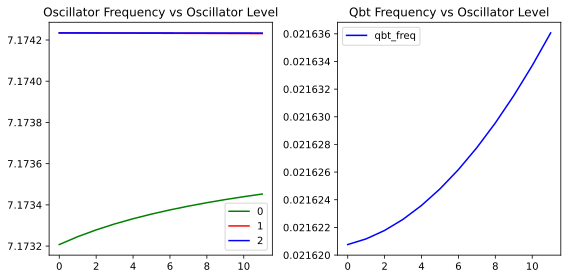

In [2]:


max_ql = 20
max_ol = 20

system = FluxoniumOscillatorSystem(
        computaional_states = '1,2',
        EJ = 2.65,
        EC = 0.6,
        EL = 0.13,
        Er = 7.17391479 ,
        qubit_level = max_ql,
        osc_level = max_ol,
        g_strength = 0.12,
        products_to_keep=[[ql, ol] for ql in [1,2,3] for ol in range(20) ] + [[ql, ol] for ql in [0] for ol in range(30) ]
        )

def plot_frequencies_qbt_osc(dressed_ener: Callable, ols):
    colors = ['green', 'red', 'blue', 'orange']

    # Create a figure and a set of subplots
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))  # Adjusted for better spacing

    # Second subplot for oscillator frequencies
    for ql in [0, 1, 2]:
        osc_energies = []
        for ol in range(0, ols - 8):
            osc_energies.append(dressed_ener(ql, ol + 1) - dressed_ener(ql, ol))
        axs[0].plot(list(range(ols - 8)), osc_energies, label=f'{ql}', color=colors[ql])
    axs[0].set_title('Oscillator Frequency vs Oscillator Level')
    axs[0].legend()
    qbt_energies = []
    for ol in range(ols-8):
        qbt_energies.append(dressed_ener(2, ol) - dressed_ener(1, ol))
    axs[1].plot(list(range(ols-8)), qbt_energies, label=f'qbt_freq', color=colors[ql])
    axs[1].set_title('Qbt Frequency vs Oscillator Level')
    axs[1].legend()

    # Show the plots
    plt.tight_layout()  # Adjust the layout to make room for the legend
    plt.show()
energies=  system.hilbertspace.eigenvals(system.qbt.truncated_dim * system.osc.truncated_dim )
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
ols = system.osc.truncated_dim
plot_frequencies_qbt_osc(dressed_ener, ols)


In [10]:
t_tot = 200
tlist = np.linspace(0, t_tot, t_tot)
results = system.run_dq_mesolve_parrallel(
                initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(i,0)])) 
                                    for i in range(3)],
                tlist = tlist, 
                drive_terms = [DriveTerm( 
                                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.osc.n_operator)),
                                pulse_shape_func=square_pulse_with_rise_fall,
                                pulse_shape_args={
                                    'w_d': 7.1732,
                                    'amp': 0.002,
                                    't_rise': 30,
                                    't_square': 10000
                                })],                        
                c_ops  = 1e-3 * system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.osc.annihilation_operator)),
                e_ops = [system.a_trunc.dag()*system.a_trunc],
                post_processing = ['pad_back','partial_trace_computational_states'],)

Processing states with dressed_to_2_level_dm: 100%|██████████| 200/200 [00:00<00:00, 1027.95it/s]


In [3]:
t_tot = 200
tlist = np.linspace(0, t_tot, t_tot)
results = system.run_dq_mesolve_parrallel(
                initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(i,0)])) 
                                    for i in range(1)],
                tlist = tlist, 
                drive_terms = [DriveTerm( 
                                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.osc.n_operator)),
                                pulse_shape_func=square_pulse_with_rise_fall,
                                pulse_shape_args={
                                    'w_d': 7.1732,
                                    'amp': 0.002,
                                    't_rise': 30,
                                    't_square': 10000
                                })],                        
                c_ops  = 1e-3 * system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.osc.annihilation_operator)),
                e_ops = [system.a_trunc.dag()*system.a_trunc],
                post_processing = ['pad_back','partial_trace_computational_states'],)

==== Result ====
Solver  : Tsit5
States  : Array complex128 (1, 200, 80, 80) | 19.53 Mb
Expects : Array complex128 (1, 1, 200) | 3.12 Kb
Infos   : avg. 238140.0 steps (238120.0 accepted, 20.0 rejected) | infos shape (1,)


Processing states with dressed_to_2_level_dm: 100%|██████████| 200/200 [00:00<00:00, 1030.16it/s]


| concurrency(# of simulation)      | system size       | simulation time   |time to run  |
| -----------                       | -----------       |-----------------  |-------------|
| 3 sesolve                         | 90                |50                 |40 s         |
| 3 sesolve                         | 90                |200                |3min        |
| 3 sesolve                         | 90                |1000               |18min       |
| 3 mesolve                         | 90                |50                 |2 min 40 s   |
| 3 mesolve                         | 90                |200                |10min 30s       |
| 1 mesolve                         | 90                |200                |9 min 37s       |


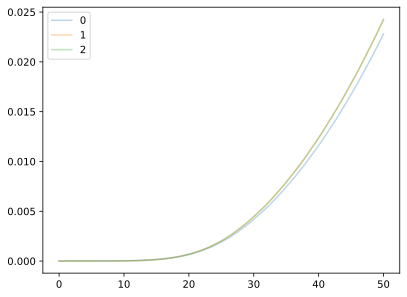

In [9]:
for i in range(3):
    plt.plot(tlist, results[i].expect[0].real,alpha= 0.3,label=f"{i}")
plt.legend()